Loading Libraries 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy import stats


Loading  the dataset

In [9]:
print(os.path.exists(r"C:\Users\Desmond\Desktop\amz_uk_price_prediction_dataset.csv"))

True


In [8]:
df = pd.read_csv("C:/Users/Desmond/Desktop/amz_uk_price_prediction_dataset.csv")

First Look 

In [10]:
print(df.shape)
print(df.dtypes)
df.head()

(2443651, 9)
uid                    int64
asin                     str
title                    str
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category                 str
dtype: object


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


Data Quality Check

In [11]:
print(df.isnull().sum())
print(df.describe())

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64
                uid         stars       reviews         price  \
count  2.443651e+06  2.443651e+06  2.443651e+06  2.443651e+06   
mean   1.370545e+06  2.152836e+00  4.806278e+02  8.924381e+01   
std    8.160562e+05  2.194865e+00  5.944124e+03  3.456089e+02   
min    1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    6.589215e+05  0.000000e+00  0.000000e+00  9.990000e+00   
50%    1.349029e+06  0.000000e+00  0.000000e+00  1.909000e+01   
75%    2.060686e+06  4.400000e+00  5.900000e+01  4.599000e+01   
max    2.828593e+06  5.000000e+00  1.356658e+06  1.000000e+05   

       boughtInLastMonth  
count       2.443651e+06  
mean        2.589699e+01  
std         2.404837e+02  
min         0.000000e+00  
25%         0.000000e+00  
50%         0.000000e+00  
75%  

Frequency Table Top 5 

In [12]:
freq_table = df['category'].value_counts()
print(freq_table.head(10))

top5 = freq_table.head(5)
print("\nTop 5 categories:")
print(top5)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64

Top 5 categories:
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


Bar Chart top 15

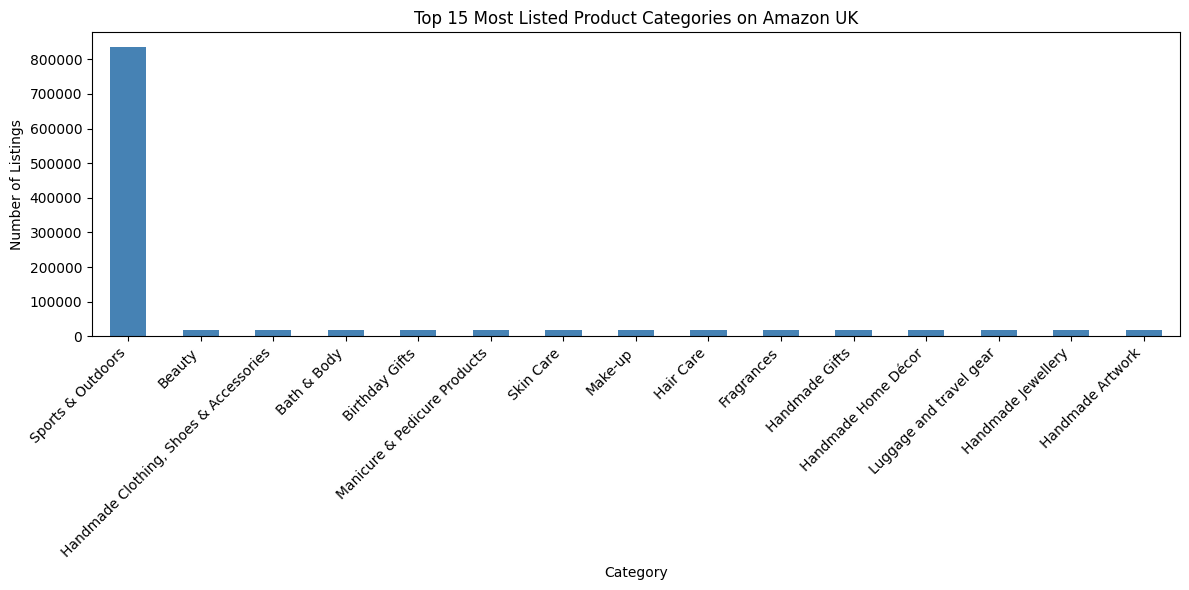

In [13]:
top15 = freq_table.head(15)

plt.figure(figsize=(12, 6))
top15.plot(kind='bar', color='steelblue')
plt.title('Top 15 Most Listed Product Categories on Amazon UK')
plt.xlabel('Category')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Pie Chart  top 5 

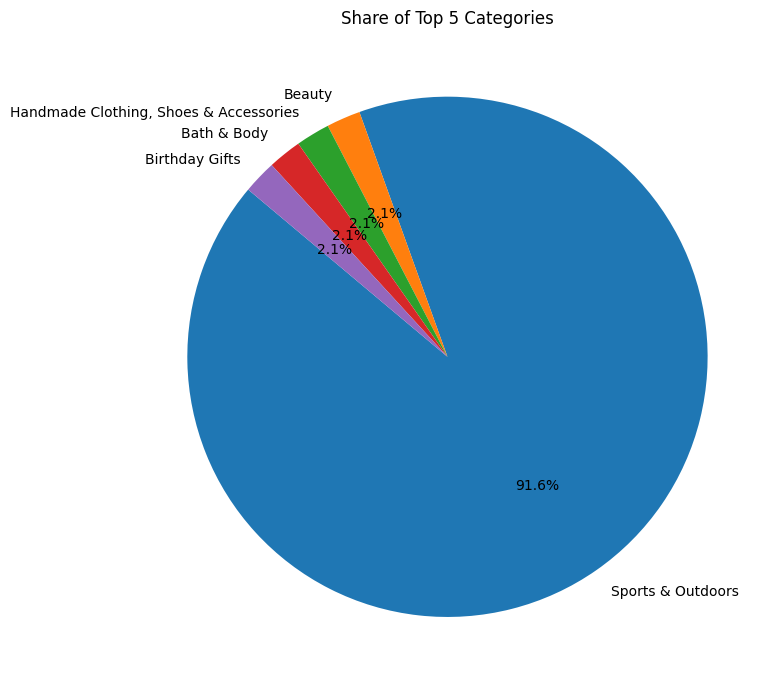

In [14]:
plt.figure(figsize=(8, 8))
top5.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Share of Top 5 Categories')
plt.ylabel('')
plt.tight_layout()
plt.show()

Product Pricing

Centrality 

In [15]:
price = df['price'].dropna()

mean_price   = price.mean()
median_price = price.median()
mode_price   = price.mode()[0]

print(f"Mean:   £{mean_price:.2f}")
print(f"Median: £{median_price:.2f}")
print(f"Mode:   £{mode_price:.2f}")

Mean:   £89.24
Median: £19.09
Mode:   £9.99


Dispersion

In [16]:
print(f"Variance:  {price.var():.2f}")
print(f"Std Dev:   {price.std():.2f}")
print(f"Range:     {price.max() - price.min():.2f}")
print(f"IQR:       {price.quantile(0.75) - price.quantile(0.25):.2f}")

Variance:  119445.49
Std Dev:   345.61
Range:     100000.00
IQR:       36.00


Histogram


 Raw 

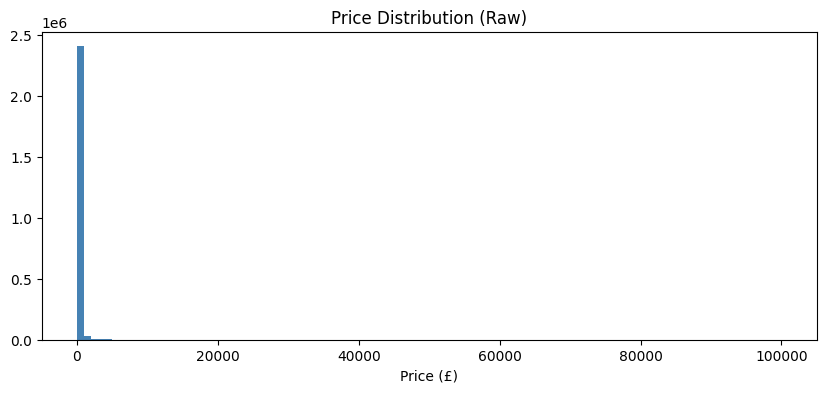

In [17]:

plt.figure(figsize=(10, 4))
plt.hist(price, bins=100, color='steelblue')
plt.title('Price Distribution (Raw)')
plt.xlabel('Price (£)')
plt.show()


Capped at 95th percentile — much more readable

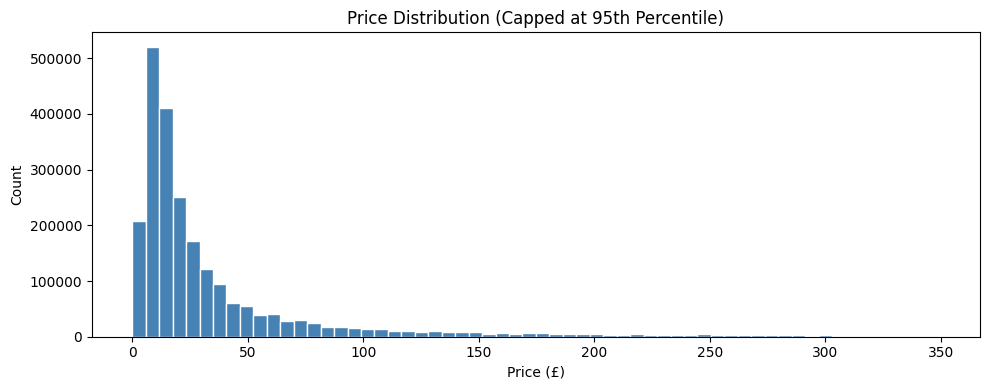

In [18]:
cap = price.quantile(0.95)
plt.figure(figsize=(10, 4))
plt.hist(price[price <= cap], bins=60, color='steelblue', edgecolor='white')
plt.title('Price Distribution (Capped at 95th Percentile)')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

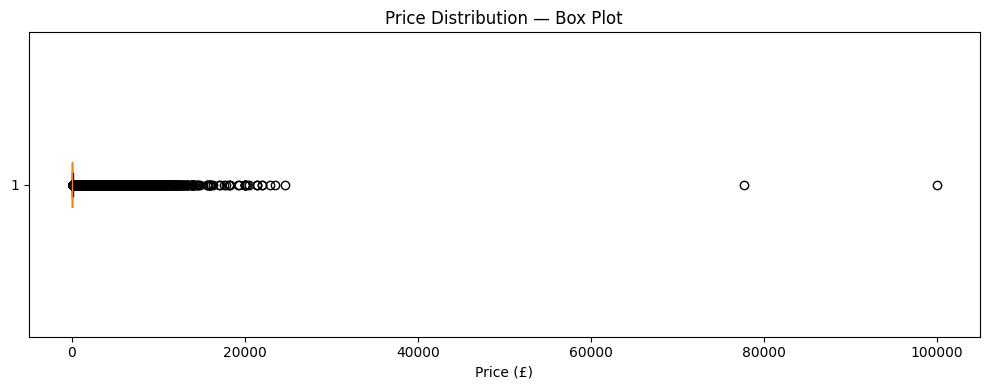

In [19]:
plt.figure(figsize=(10, 4))
plt.boxplot(price, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Price Distribution — Box Plot')
plt.xlabel('Price (£)')
plt.tight_layout()
plt.show()

Product Ratings 

Centrality 

In [24]:
stars = pd.to_numeric(df["stars"], errors="coerce").dropna()

print(f"Mean:   {stars.mean():.2f}")
print(f"Median: {stars.median():.2f}")
print(f"Mode:   {stars.mode().iloc[0]:.2f}")

Mean:   2.15
Median: 0.00
Mode:   0.00


Dispersion:Skewness & Kurtosis:

In [27]:
stars = pd.to_numeric(df["stars"], errors="coerce").dropna()

In [28]:
print(f"Variance: {stars.var():.4f}")
print(f"Std Dev:  {stars.std():.4f}")
print(f"IQR:      {stars.quantile(0.75) - stars.quantile(0.25):.4f}")
print(f"Skewness: {stars.skew():.4f}")
print(f"Kurtosis: {stars.kurt():.4f}")

Variance: 4.8174
Std Dev:  2.1949
IQR:      4.4000
Skewness: 0.0812
Kurtosis: -1.9260


Histogram

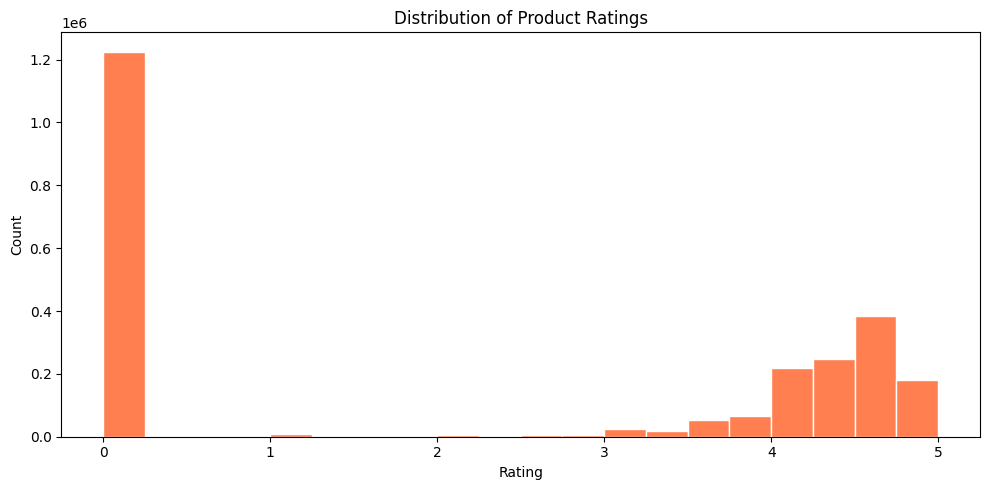

In [ ]:
stars = pd.to_numeric(df["stars"], errors="coerce").dropna()

plt.figure(figsize=(10, 5))
plt.hist(stars, bins=20, color="coral", edgecolor="white")
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

 1 Findings
The top 5 categories are [...]. Category X dominates with Y% of all listings,
suggesting high seller competition in that space. Businesses entering this market
should assess saturation before committing.

2 Findings
The mean price (£X) is significantly higher than the median (£Y), indicating
right skew driven by luxury/premium outliers. The IQR of £Z suggests most products
sit in a tighter range. A pricing strategy targeting the £[median range] would
align with the bulk of the market.

Part 3 Findings
The average rating of X.X with a mode of Y.Y suggests customers generally
rate products positively. The skewness of [value] confirms a [left/right]-skewed
distribution — [interpretation]. Low variance (Z) indicates ratings are relatively
consistent across the platform.